# Figure S14B-F. Reference-based activity filters

In [1]:
### load packages
import math
import glob

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
plt.rcParams.update({'font.size': 14})

import os
import random
import numpy as np

# Set all possible seeds
np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [2]:
# ### Create samplesheet for liang enriched paired samples
# # liang_enriched_samples.tsv identified by finding samples with a viromeQC score >= 50
# # downloaded from here: https://pmc.ncbi.nlm.nih.gov/articles/instance/10925137/bin/media-3.xlsx
# # liang_sample_file.tsv is the file downloaded from SRA

# liang_enriched_samples = set(
#     pl.read_csv('liang_enriched_samples.tsv', separator='\t')
#         .with_columns([
#             pl.col('sample_id').str.replace(r'^D', '')
#         ])
#         ['sample_id']
# )

# liang_enriched_paired_samples = set(
#     pl.read_csv('liang_sample_file.tsv', separator='\t', ignore_errors=True)
#         .with_columns([
#             pl.col('Sample_id').cast(pl.String)
#         ])
#         .filter(
#             (pl.col('Sample_id').is_in(liang_enriched_samples)) &
#             (pl.col('Note').str.contains('infant stool')) &
#             (~pl.col('Note').str.starts_with('RNA '))
#         )
#         .group_by('Sample_id')
#         .len()
#         .filter(pl.col('len') == 2)
#         ['Sample_id']
# )

# (
#     pl.read_csv('liang_sample_file.tsv', separator='\t', ignore_errors=True)
#         .with_columns([
#             pl.col('Sample_id').cast(pl.String)
#         ])
#         .filter(
#             (pl.col('Sample_id').is_in(liang_enriched_paired_samples)) &
#             (~pl.col('Note').str.starts_with('RNA ')) &
#             (pl.col('Library_type').is_in(['Virome sequencing', 'Total microbial shotgun  sequencing']))
#         )
#         .with_columns([
#             pl.when(pl.col('Library_type') == 'Virome sequencing').then(pl.lit('enriched')).otherwise(pl.lit('unenriched')).alias('sample_type')
#         ])
#         .with_columns([
#             ('liang_' + pl.col('Sample_id') + '_' + pl.col('sample_type')).alias('sample'),
#             pl.col('Bioproject_accession').alias('bioproject'),
#             ('liang_' + pl.col('Sample_id')).alias('group'),
#             pl.col('Biosample_accession').alias('biosample'),
#             pl.col('Accession').alias('acc'),
#             pl.lit(None).alias('fastq_1'),
#             pl.lit(None).alias('fastq_2')
#         ])
#         [['sample', 'bioproject', 'group', 'biosample', 'acc', 'fastq_1', 'fastq_2']]
#         .write_csv('liang_enriched_paired_samplesheet.csv', separator=',')
# )

In [3]:
# %%bash
# ### run through UHVDB/toolkit
# mkdir -p activity_profiling/liang_enriched_results
# cd activity_profiling/liang_enriched_results

# nextflow run /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit \
#     -profile uw_hyak \
#     -w /gscratch/scrubbed/carsonjm/2026.03.26-liang_enriched_results/work \
#     --input /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/activity_profiling/liang_enriched_paired_samplesheet.csv \
#     --db_dir /gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/UHVDB/toolkit/databases \
#     --checkv_db /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/checkv_db/checkv_db_2026-03-26-2 \
#     --output_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/activity_profiling/liang_enriched_results \
#     --uhvdb_dir /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2 \
#     --hyak_partition="stf" \
#     --hyak_queue="ckpt" \
#     --new_release_id="2026-04-03" \
#     --run_reference_analyze=true \
#     --bacterial_sylph_db=/mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_4/virome_profiling/gtdb-r226-c1000-dbv1.syldb \
#     --run_assembly_analyze=true

In [4]:
# %%bash
# ### Count number of species reps
# zgrep -c "^>" /mmfs1/gscratch/pedslabs_hoffman/carsonjm/CFPhageome/repos/uhvdb-manuscript/figure_1/uhvdb_human_metag_results/uhvdb_2026-03-26-2/uhvdb_species_reps.fna.gz

In [5]:
### load coverm results to identify viruses detected in bulk and enriched
df_lst = []

for file in glob.glob('../figure_4/activity_profiling/liang_enriched_results/2026-04-03_outputs/referenceanalyze/coverm/*/*.coverm.tsv.gz'):
    sample_id = file.split('/')[-1].split('.')[0]
    group = sample_id.rsplit('_', 1)[0]
    df = (
        pl.read_csv(file, separator='\t', new_columns=['contig_id', 'trimmed_mean', 'mean', 'variance', 'covered_bases', 'length'])
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.lit(group).alias('group')
            ])
            .with_columns([
                (pl.col('covered_bases')/pl.col('length')).alias('breadth'),
            ])
            .with_columns([
                (1 - math.e**(-0.833 * pl.col('mean'))).alias('expected_breadth'),
            ])
            .with_columns([
                (pl.col('breadth')/pl.col('expected_breadth')).alias('breadth_ratio'),
            ])
    )
    df_lst.append(df)

coverm_df = pl.concat(df_lst)

In [6]:
### Calculate phage host ratio
phage_host_ratio_lst = []
sylph_tax_results = []

for file in glob.glob('../figure_4/sylph_tax_results/*.sylphmpa'):
    sample_id=file.split('/')[-1].split('.syl')[0]
    df = pl.read_csv(file, separator='\t', skip_rows=1, new_columns=['clade_name', 'taxonomic_abundance', 'relative_abundance', 'ani', 'coverage', 'virus_host'], null_values=['NA'], schema_overrides={'clade_name': pl.Utf8, 'taxonomic_abundance': pl.Float64, 'relative_abundance': pl.Float64, 'ani': pl.Float64, 'coverage': pl.Float64, 'virus_host': pl.Utf8})
    virus_df = (
        df
            .filter(pl.col('virus_host').is_not_null())
            .with_columns([pl.col('virus_host').str.replace_all(';', '|')])
    )
    sylph_tax_results.append(
        df
            .filter(pl.col('clade_name').str.starts_with('Viruses'))
            .filter(pl.col('clade_name').str.contains('t__'))
            .with_columns([
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])
    )
    bac_df = df.filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
    phage_host_ratio_lst.append(
        virus_df
            .join(bac_df, left_on='virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('phage_host_ratio'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Int64).alias('species_cluster_id'),
            ])
    )

phage_host_ratio_df = pl.concat(phage_host_ratio_lst)[['sample_id', 'species_cluster_id', 'phage_host_ratio']]
sylph_tax_results_df = pl.concat(sylph_tax_results)

In [7]:
# load final metadata and get species consensus
uhvdb_final_metadata = pl.read_csv('../figure_s17/uhvdb_v5_final_metadata.tsv.gz', separator='\t')
genome_to_species = uhvdb_final_metadata.select(['uhvdb_id', 'species_cluster_id']).unique()

In [8]:
# aggregate to species level
uhvdb_final_metadata_species = (
    coverm_df
        .filter(pl.col('sample_id').str.contains('_unenriched'))
        .join(
            coverm_df.filter(pl.col('sample_id').str.contains('_enriched')),
            on=['group', 'contig_id'], suffix='_enriched', how='full'
        )
        .filter(pl.col('contig_id').is_not_null())
        .join(genome_to_species, left_on='contig_id', right_on='uhvdb_id', how='left')
        .join(uhvdb_final_metadata, on='species_cluster_id', how='left')
        .filter(pl.col('seq_name') == pl.col('seqhash_rep'))
        .filter(pl.col('contig_id') == pl.col('genomovar_rep'))
        .group_by(['species_cluster_id', 'sample_id', 'group'])
        .agg([
            (pl.col('checkv_quality') == 'Complete').sum().alias('complete_count'),
            (pl.col('checkv_quality') == 'High-quality').sum().alias('high_quality_count'),
            (pl.col('n_hallmarks')).median().alias('med_n_hallmarks'),
            ((pl.col('aai_id')/100) * pl.col('aai_af')).median().alias('med_aai_id_af'),
            (pl.col('viral_genes')).median().alias('med_viral_genes'),
            (pl.col('host_genes')).median().alias('med_host_genes'),
            # identify most common ictv class
            pl.col('ictv_class').mode().alias('most_common_ictv_class'),
            pl.col('family_cluster_id').mode().alias('most_common_family_cluster_id'),
            # get the most common family
            pl.col('host_lineage').mode().alias('most_common_host_taxonomy'),
            pl.col('phist_genus_connections').median().alias('med_phist_genus_connections'),
            pl.col('phist_species_connections').median().alias('med_phist_species_connections'),
            pl.col('phist_family_connections').median().alias('med_phist_family_connections'),
            pl.col('crispr_genus_connections').median().alias('med_crispr_genus_connections'),
            pl.col('crispr_species_connections').median().alias('med_crispr_species_connections'),
            pl.col('crispr_family_connections').median().alias('med_crispr_family_connections'),
            (pl.col('virulent').median()).alias('med_virulent_score'),
            ((pl.col('phrog_integration_excision')).median() + (pl.col('empathi_integration')).median()).alias('med_integration_related'),
            (pl.col('num_uniprot_ips').median() / pl.col('num_proteins').median()).alias('mean_proportion_uniprot_ips'),
            (pl.col('num_capsid').median()).alias('med_num_capsid'),
            (pl.col('num_tail').median()).alias('med_num_tail'),
            (pl.col('num_lysis').median()).alias('med_num_lysis'),
            (pl.col('mcp_hallmark').median()).alias('med_mcp_hallmark'),
            (pl.col('terl_hallmark').median()).alias('med_terL_hallmark'),
            (pl.col('portal_hallmark').median()).alias('med_portal_hallmark'),
            (pl.col('breadth').median()).alias('breadth'),
            (pl.col('breadth_enriched').median()).alias('breadth_enriched'),
            (pl.col('breadth_ratio').median()).alias('breadth_ratio'),
            (pl.col('breadth_ratio_enriched').median()).alias('breadth_ratio_enriched'),
            (pl.col('variance').median()).alias('variance'),
            (pl.col('trimmed_mean').median()).alias('trimmed_mean'),
            (pl.col('length').median()).alias('genome_length'),
        ])
        .join(phage_host_ratio_df, left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .join(sylph_tax_results_df.select(['species_cluster_id', 'sample_id', 'ani']), left_on=['sample_id', 'species_cluster_id'], right_on=['sample_id', 'species_cluster_id'], how='left')
        .unique(['species_cluster_id', 'sample_id'])
        .fill_null(0.00)
)
uhvdb_final_metadata_species.head(1)

species_cluster_id,sample_id,group,complete_count,high_quality_count,med_n_hallmarks,med_aai_id_af,med_viral_genes,med_host_genes,most_common_ictv_class,most_common_family_cluster_id,most_common_host_taxonomy,med_phist_genus_connections,med_phist_species_connections,med_phist_family_connections,med_crispr_genus_connections,med_crispr_species_connections,med_crispr_family_connections,med_virulent_score,med_integration_related,mean_proportion_uniprot_ips,med_num_capsid,med_num_tail,med_num_lysis,med_mcp_hallmark,med_terL_hallmark,med_portal_hallmark,breadth,breadth_enriched,breadth_ratio,breadth_ratio_enriched,variance,trimmed_mean,genome_length,phage_host_ratio,ani
f64,str,str,f64,f64,f64,f64,f64,f64,list[str],list[i64],list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2073.0,"""liang_370_unenriched""","""liang_370""",0.0,1.0,9.0,84.600776,9.0,2.0,"[""Caudoviricetes""]",[41],"[""d__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae""]",0.0,0.0,1055.0,0.0,0.0,0.0,0.9625,4.0,0.93617,4.0,9.0,2.0,1.0,1.0,1.0,0.889535,0.0,0.889535,0.0,15051.658,196.41562,46757.0,3.13177,97.22


In [9]:
print("Number of true positives:", uhvdb_final_metadata_species.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false negatives:", uhvdb_final_metadata_species.filter((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6)).height)
print("Number of false positives:", uhvdb_final_metadata_species.filter((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6)).height)

enrich_v_unenrich = (
    uhvdb_final_metadata_species
        .with_columns([
            pl.when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('TP'))
                .when((pl.col('breadth_ratio') < 0.6) & (pl.col('breadth_ratio_enriched') >= 0.6))
                .then(pl.lit('FN'))
                .when((pl.col('breadth_ratio') >= 0.6) & (pl.col('breadth_ratio_enriched') < 0.6))
                .then(pl.lit('FP'))
                .otherwise(pl.lit('TN'))
                .alias('pr_cat')
        ])
)

Number of true positives: 859
Number of false negatives: 21
Number of false positives: 1982


### Reference-based benchmarks

In [10]:
### Calculate precision if sequences were chosen at random
precisions = []
recalls = []

print("Number of detected species:", enrich_v_unenrich.filter(pl.col('breadth_ratio') >= 0.6).height)
print("Number of detected TPs:", enrich_v_unenrich.filter(pl.col('pr_cat') == 'TP').height)
print("Precision at random:",
    enrich_v_unenrich.filter(pl.col('pr_cat') == 'TP').height /
    enrich_v_unenrich.filter(pl.col('breadth_ratio') >= 0.6).height
)

Number of detected species: 2841
Number of detected TPs: 859
Precision at random: 0.30235832453361494


1.0


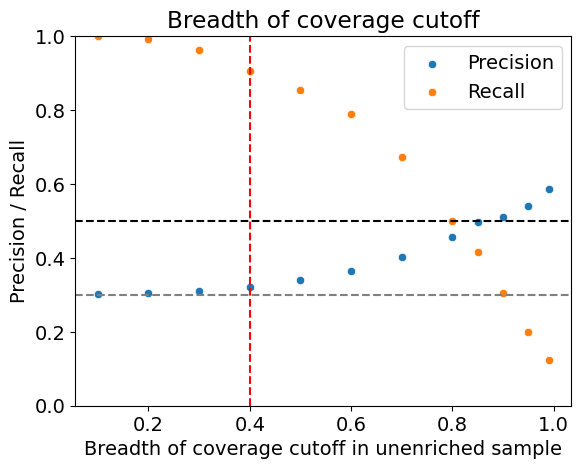

In [11]:
### breadth of coverage cutoffs
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.30, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.4, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth of coverage cutoff in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('Breadth of coverage cutoff')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

1.0


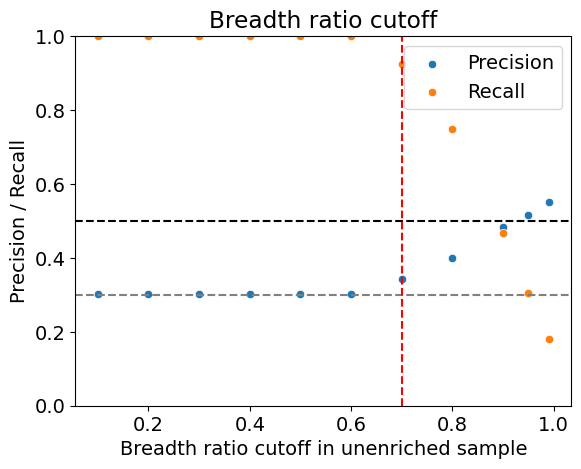

In [12]:
### breadth ratio of coverage cutoffs
precision_values = []
recall_values = []

print(enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('breadth_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.30, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.7, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Breadth ratio cutoff in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('Breadth ratio cutoff')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

1.0


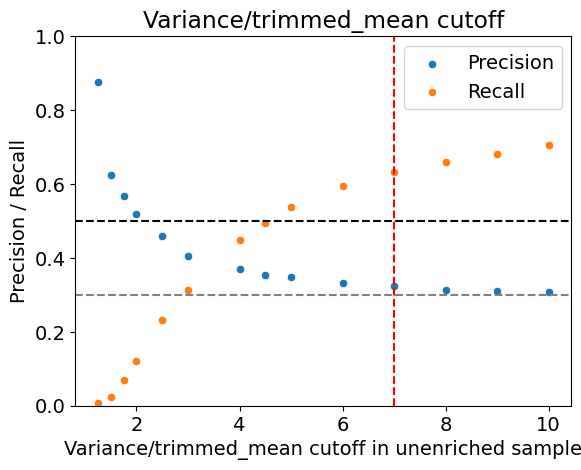

In [13]:
### variance of coverage cutoffs
precision_values = []
recall_values = []

print(enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.5, 3, 2.5, 4, 4.5, 5, 6, 7, 8, 9, 10]:
    # skip if less than 3 true positives
    if (enrich_v_unenrich
            .filter((pl.col('variance')/pl.col('trimmed_mean')) <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    # calculate precision and recall
    precision_values.append(
        enrich_v_unenrich
            .filter((pl.col('variance')/pl.col('trimmed_mean')) <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('variance')/pl.col('trimmed_mean')) <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter((pl.col('variance')/pl.col('trimmed_mean')) <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.5, 3, 2.5, 4, 4.5, 5, 6, 7, 8, 9, 10],
    y=precision_values
)
sns.scatterplot(
    x=[0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 2.5, 3, 2.5, 4, 4.5, 5, 6, 7, 8, 9, 10],
    y=recall_values
)
plt.axhline(y=0.30, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=7, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Variance/trimmed_mean cutoff in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('Variance/trimmed_mean cutoff')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.5669383003492433


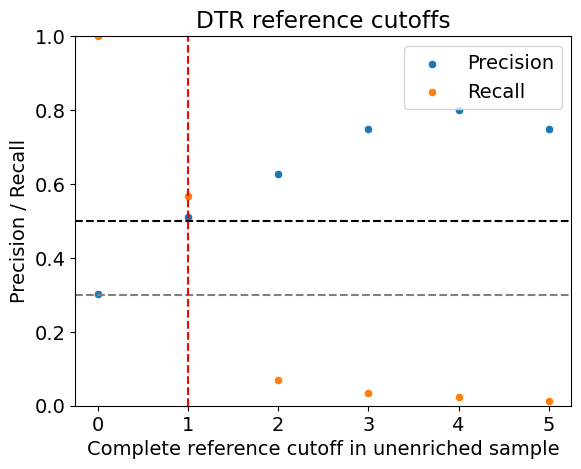

In [14]:
### Reference DTR
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('complete_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 1, 2, 3, 4, 5, 10, 15, 20, 25]:
    if (enrich_v_unenrich
            .filter(pl.col('complete_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('complete_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('complete_count') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('complete_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.xlabel('Complete reference cutoff in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('DTR reference cutoffs')
plt.ylim(0,1)
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.5494761350407451


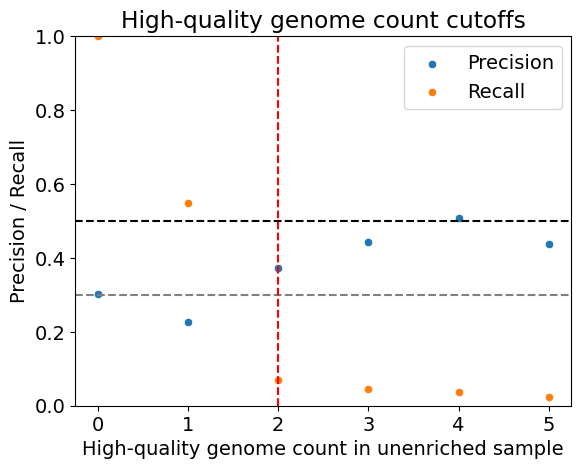

In [15]:
### High-quality genome count
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('high_quality_count') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [0, 1, 2, 3, 4, 5, 10, 15, 20, 25]:
    if (enrich_v_unenrich
            .filter(pl.col('high_quality_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('high_quality_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('high_quality_count') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('high_quality_count') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=precision_values
)
sns.scatterplot(
    x=[0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=2, color='red', linestyle='--')
plt.xlabel('High-quality genome count in unenriched sample')
plt.ylabel('Precision / Recall')
plt.title('High-quality genome count cutoffs')
plt.ylim(0,1)
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.19674039580908032


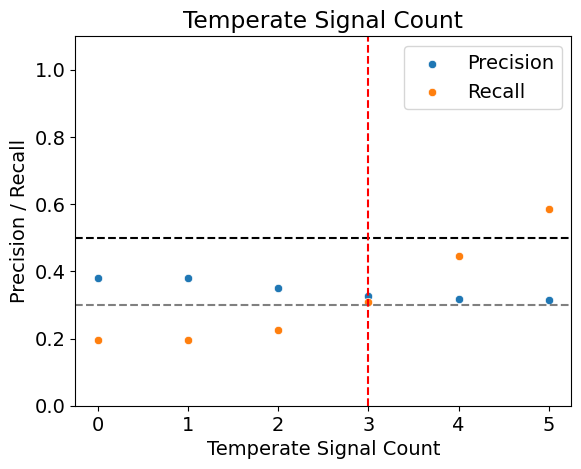

In [16]:
### Temperate signal count
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_integration_related') == 0.0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 0, 1, 2, 3, 4, 5]:
    if (enrich_v_unenrich
            .filter(pl.col('med_integration_related') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_integration_related') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_integration_related') <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_integration_related') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=3, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Temperate Signal Count')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('Temperate Signal Count')
plt.show()

0.26658905704307334


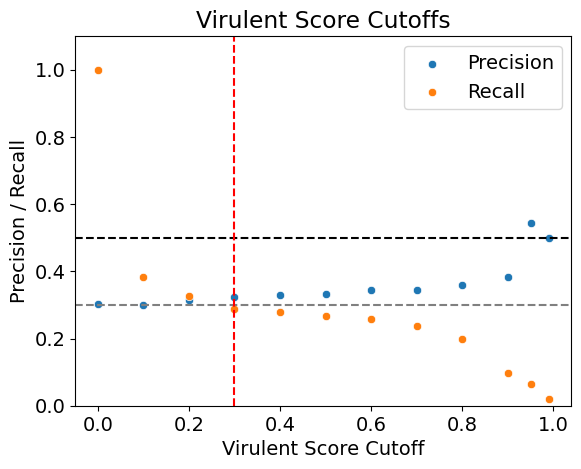

In [17]:
### Virulent score cutoffs
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_virulent_score') > 0.5)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]:
    if (enrich_v_unenrich
            .filter(pl.col('med_virulent_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_virulent_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_virulent_score') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_virulent_score') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.3, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Virulent Score Cutoff')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('Virulent Score Cutoffs')
plt.show()

0.989522700814901


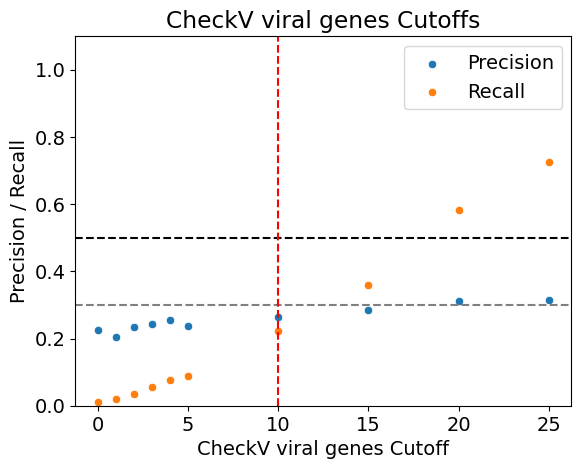

In [18]:
### CheckV viral genes
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_viral_genes') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25]:
    if (enrich_v_unenrich
            .filter(pl.col('med_viral_genes') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_viral_genes') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_viral_genes') <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_viral_genes') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=10, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('CheckV viral genes Cutoff')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('CheckV viral genes Cutoffs')
plt.show()

0.5145518044237486


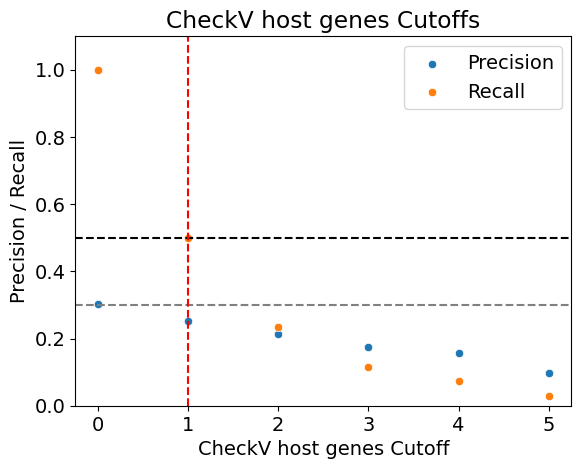

In [19]:
### CheckV host genes
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_host_genes') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25]:
    if (enrich_v_unenrich
            .filter(pl.col('med_host_genes') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_host_genes') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_host_genes') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_host_genes') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=1, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('CheckV host genes Cutoff')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('CheckV host genes Cutoffs')
plt.show()

0.9988358556461001


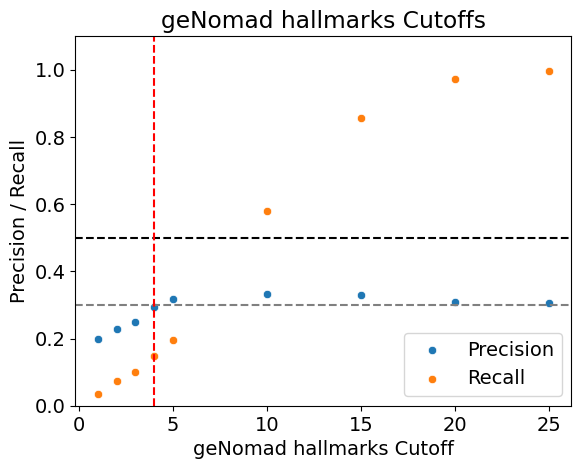

In [20]:
### CheckV viral genes
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_n_hallmarks') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)
for i in [ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25]:
    if (enrich_v_unenrich
            .filter(pl.col('med_n_hallmarks') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_n_hallmarks') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_n_hallmarks') <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_n_hallmarks') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 10, 15, 20, 25],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=4, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('geNomad hallmarks Cutoff')
plt.ylabel('Precision / Recall')
plt.legend(labels=['Precision', 'Recall'])
plt.title('geNomad hallmarks Cutoffs')
plt.show()

0.4330616996507567


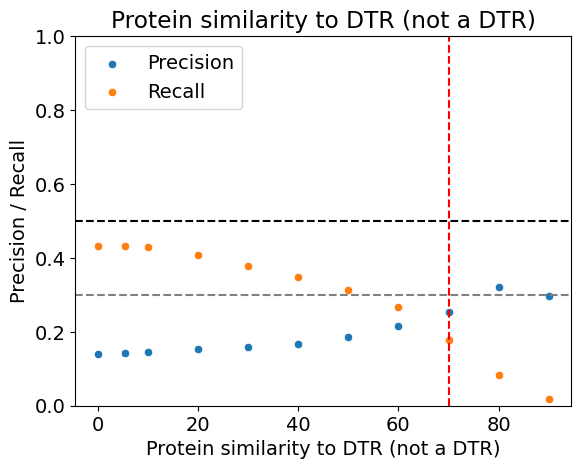

In [21]:
### Protein similarity to DTR (Not DTR)
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_aai_id_af') > 0)
            .filter(pl.col('complete_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ]:
    if (enrich_v_unenrich
            .filter(pl.col('med_aai_id_af') >= i)
            .filter(pl.col('complete_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_aai_id_af') >= i)
            .filter(pl.col('complete_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_aai_id_af') >= i)
            .filter(pl.col('complete_count') == 0)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_aai_id_af') >= i)
            .filter(pl.col('complete_count') == 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 5.5, 10, 20, 30, 40, 50, 60, 70, 80, 90 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=70, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Protein similarity to DTR (not a DTR)')
plt.ylabel('Precision / Recall')
plt.title('Protein similarity to DTR (not a DTR)')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

1.0


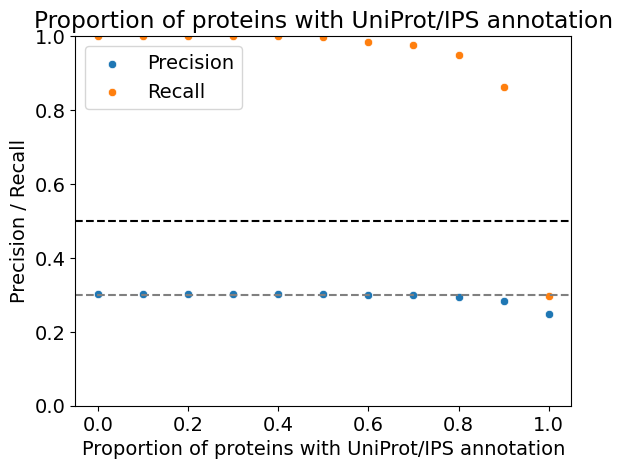

In [22]:
### Prop to UniProt/IPS
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('mean_proportion_uniprot_ips') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ]:
    if (enrich_v_unenrich
            .filter(pl.col('mean_proportion_uniprot_ips') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('mean_proportion_uniprot_ips') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('mean_proportion_uniprot_ips') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('mean_proportion_uniprot_ips') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
# plt.axvline(x=80, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Proportion of proteins with UniProt/IPS annotation')
plt.ylabel('Precision / Recall')
plt.title('Proportion of proteins with UniProt/IPS annotation')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.9289871944121071


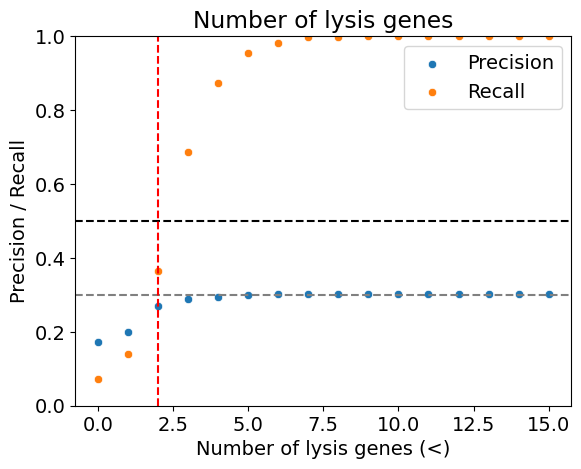

In [23]:
### Number of lysis genes
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_num_lysis') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ]:
    if (enrich_v_unenrich
            .filter(pl.col('med_num_lysis') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_num_lysis') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_num_lysis') <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_num_lysis') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=2, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Number of lysis genes (<)')
plt.ylabel('Precision / Recall')
plt.title('Number of lysis genes')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.9813736903376019


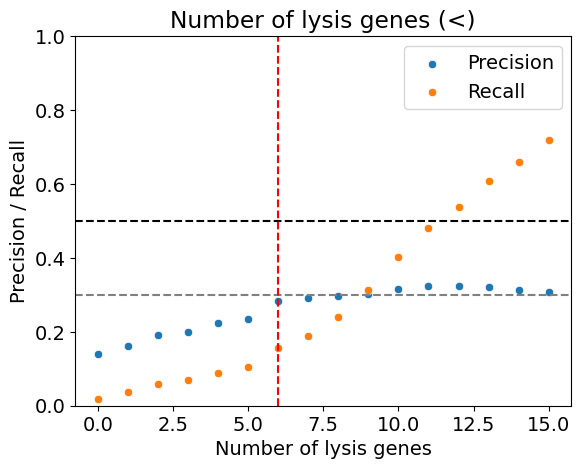

In [24]:
### Number of tail genes
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_num_tail') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ]:
    if (enrich_v_unenrich
            .filter(pl.col('med_num_tail') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_num_tail') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_num_tail') <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_num_tail') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=6, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Number of lysis genes')
plt.ylabel('Precision / Recall')
plt.title('Number of lysis genes (<)')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.9941792782305006


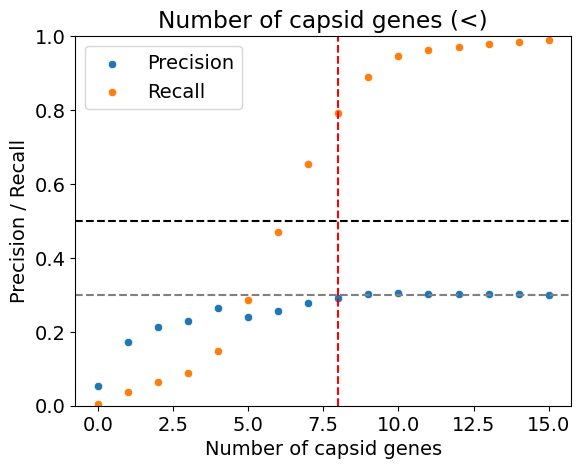

In [25]:
### Number of capsid genes
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter(pl.col('med_num_capsid') > 0)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ]:
    if (enrich_v_unenrich
            .filter(pl.col('med_num_capsid') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_num_capsid') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('med_num_capsid') <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('med_num_capsid') <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=8, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Number of capsid genes')
plt.ylabel('Precision / Recall')
plt.title('Number of capsid genes (<)')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

0.9743888242142026


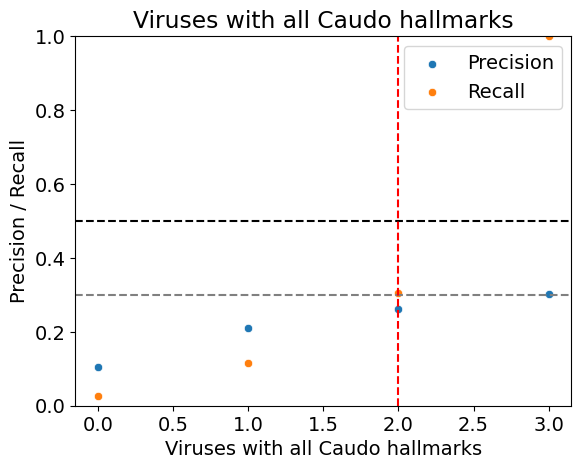

In [26]:
### Number of hallmarks
precision_values = []
recall_values = []
print(enrich_v_unenrich
            .filter((pl.col('med_mcp_hallmark') > 0) + (pl.col('med_terL_hallmark') > 0) + (pl.col('med_portal_hallmark') > 0) >= 1)
            .filter((pl.col('pr_cat') == 'TP'))
            .height /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
)

for i in [ 0, 1, 2, 3 ]:
    if (enrich_v_unenrich
            .filter((pl.col('med_mcp_hallmark') > 0) + (pl.col('med_terL_hallmark') > 0) + (pl.col('med_portal_hallmark') > 0) <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter((pl.col('med_mcp_hallmark') > 0) + (pl.col('med_terL_hallmark') > 0) + (pl.col('med_portal_hallmark') > 0) <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('med_mcp_hallmark') > 0) + (pl.col('med_terL_hallmark') > 0) + (pl.col('med_portal_hallmark') > 0) <= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(((pl.col('med_mcp_hallmark') > 0) + (pl.col('med_terL_hallmark') > 0) + (pl.col('med_portal_hallmark') > 0)) <= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 1, 2, 3 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 1, 2, 3 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=2, color='red', linestyle='--')
plt.ylim(0, 1)
plt.xlabel('Viruses with all Caudo hallmarks')
plt.ylabel('Precision / Recall')
plt.title('Viruses with all Caudo hallmarks')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

In [27]:
%%bash
# mkdir -p sylph_tax_results

# for file in activity_profiling/liang_enriched_results/2026-04-03_outputs/referenceanalyze/sylph/liang_*_unenriched/liang_*_unenriched.profile.tsv; do
#     base=$(basename $file)
#     sylph-tax taxprof \
#         ${file} \
#         -t ../figure_s16/uhvdb_cf_results/uhvdb_2026-04-03/uhvdb_sylph_metadata.tsv.gz sylph_tax/gtdb_r226_metadata.tsv.gz \
#         -a \
#         -o sylph_tax_results/${base%.profile.tsv}.sylph-tax
# done

In [28]:
phage_host_ratio_lst = []

for file in glob.glob('../figure_4/sylph_tax_results/*.sylphmpa'):
    sample_id=file.split('/')[-1].split('.syl')[0]
    df = pl.read_csv(file, separator='\t', skip_rows=1, new_columns=['clade_name', 'taxonomic_abundance', 'relative_abundance', 'ani', 'coverage', 'virus_host'], null_values=['NA'], schema_overrides={'clade_name': pl.Utf8, 'taxonomic_abundance': pl.Float64, 'relative_abundance': pl.Float64, 'ani': pl.Float64, 'coverage': pl.Float64, 'virus_host': pl.Utf8})
    virus_df = df.filter(pl.col('virus_host').is_not_null()).with_columns([pl.col('virus_host').str.replace_all(';', '|')])
    bac_df = df.filter(pl.col('clade_name').str.starts_with('d__Bacteria'))
    phage_host_ratio_lst.append(
        virus_df
            .join(bac_df, left_on='virus_host', right_on='clade_name', how='inner')
            .with_columns([
                (pl.col('taxonomic_abundance') / pl.col('taxonomic_abundance_right')).alias('phage_host_ratio'),
                pl.lit(sample_id).alias('sample_id'),
                pl.col('clade_name').str.split('t__').list[1].alias('votu_rep'),
                pl.col('clade_name').str.replace(r'.*vSPECIES-', '').str.replace(r'\|.*', '').cast(pl.Float64).alias('species_cluster_id'),
            ])
    )

phage_host_ratio_df = pl.concat(phage_host_ratio_lst)

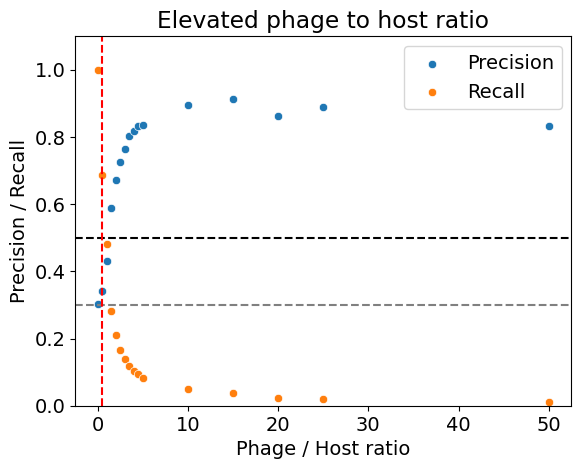

In [29]:
### Phage-to-host ratio
precision_values = []
recall_values = []

for i in [ 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5, 4, 4.5, 5, 10, 15, 20, 25, 50 ]:
    if (enrich_v_unenrich
            .filter(pl.col('phage_host_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('phage_host_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('phage_host_ratio') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('phage_host_ratio') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5, 4, 4.5, 5, 10, 15, 20, 25, 50 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 0, 0.5, 1.0, 1.5, 2.0, 2.5, 3, 3.5, 4, 4.5, 5, 10, 15, 20, 25, 50 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=0.5, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('Phage / Host ratio')
plt.ylabel('Precision / Recall')
plt.title('Elevated phage to host ratio')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

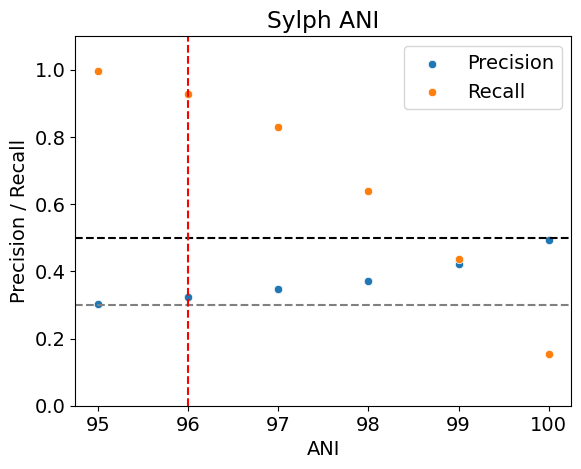

In [30]:
### Sylph ANI
precision_values = []
recall_values = []

for i in [ 95, 96, 97, 98, 99, 100 ]:
    if (enrich_v_unenrich
            .filter(pl.col('ani') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        ) < 3:
        precision_values.append(None)
        recall_values.append(None)
        continue

    precision_values.append(
        enrich_v_unenrich
            .filter(pl.col('ani') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter(pl.col('ani') >= i)
            .filter(pl.col('breadth_ratio') >= 0.6)
            .height
    )

    recall_values.append(
        enrich_v_unenrich
            .filter(pl.col('ani') >= i)
            .filter((pl.col('pr_cat') == 'TP'))
            .height
        /
        enrich_v_unenrich
            .filter((pl.col('pr_cat') == 'TP'))
            .height
    )

# scatterplot of precision vs breadth cutoff
sns.scatterplot(
    x=[ 95, 96, 97, 98, 99, 100 ],
    y=precision_values
)
sns.scatterplot(
    x=[ 95, 96, 97, 98, 99, 100 ],
    y=recall_values
)
plt.axhline(y=0.3, color='grey', linestyle='--')
plt.axhline(y=0.5, color='black', linestyle='--')
plt.axvline(x=96, color='red', linestyle='--')
plt.ylim(0, 1.1)
plt.xlabel('ANI')
plt.ylabel('Precision / Recall')
plt.title('Sylph ANI')
plt.legend(labels=['Precision', 'Recall'])
plt.show()

In [31]:
enrich_v_unenrich_final = (
    enrich_v_unenrich
    .with_columns([
        (pl.col('variance')/pl.col('trimmed_mean')).alias('variance_ratio'),
    ])
    [[
        'group', 'species_cluster_id', 'pr_cat',
        'breadth', 'breadth_ratio', 'variance_ratio', 'complete_count', 'high_quality_count',
        'med_integration_related', 'med_virulent_score', 'med_viral_genes', 'med_host_genes', 'med_n_hallmarks',
        'med_aai_id_af', 'med_num_lysis', 'med_num_tail', 'med_num_capsid', 'med_mcp_hallmark',
        'med_portal_hallmark', 'med_terL_hallmark', 'phage_host_ratio', 'ani',
    ]]
    .sort(['group', 'species_cluster_id'])
)

Starting Group K-Fold Cross-Validation (k=5)


 fold    AUROC    AUPRC      MCC
    1 0.823031 0.747461 0.444395
    2 0.819598 0.721685 0.487933
    3 0.809741 0.717736 0.433929
    4 0.828527 0.685318 0.485413
    5 0.801558 0.570282 0.420975

Pooled metrics across all folds:
  AUROC : 0.813
  AUPRC : 0.681
  MCC   : 0.449


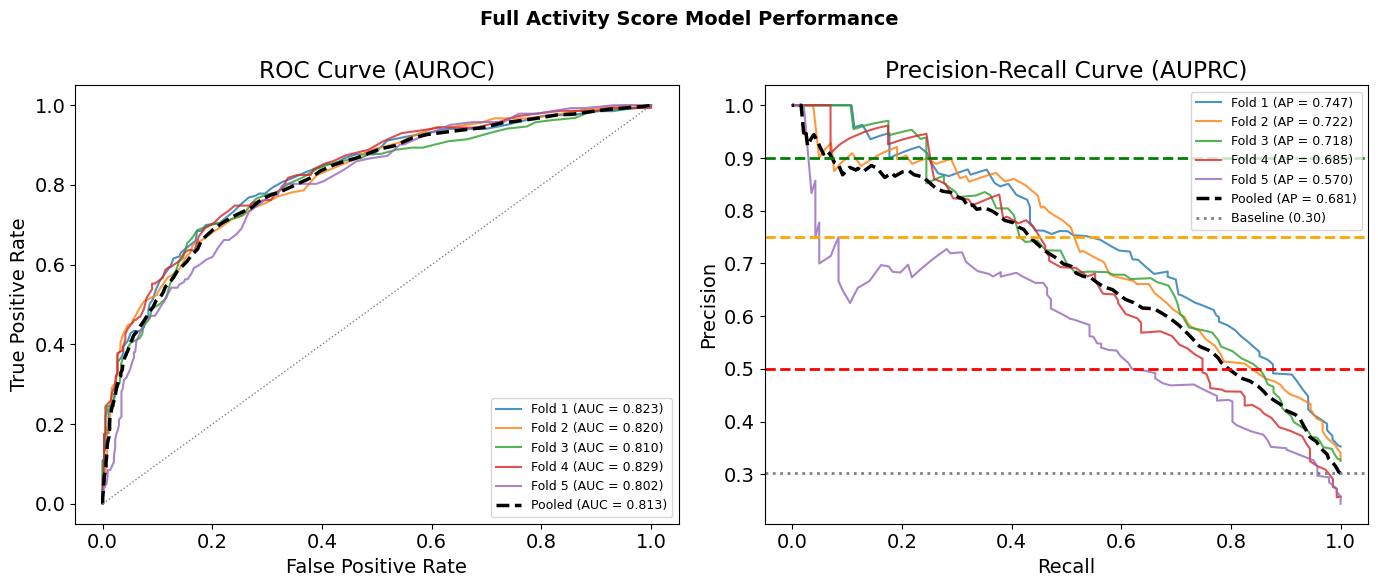

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    roc_curve,
    precision_recall_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import shap

# =============================================================================
# 1. LOAD DATA (Using the mock data dictionary)
# =============================================================================
df = enrich_v_unenrich_final.to_pandas()

# =============================================================================
# 2. DEFINE TARGET VARIABLE
# =============================================================================
df = df[df["pr_cat"].isin(["TP", "FP"])].copy()
df["is_active"] = (df["pr_cat"] == "TP").astype(int)

# =============================================================================
# 3. FEATURE ENGINEERING
# =============================================================================

# =============================================================================
# 4. DROP LEAKAGE, IDENTIFIERS, & ECOLOGY-SPECIFIC COLUMNS
# =============================================================================
cols_to_drop = [
    # Identifiers & Targets
    "species_cluster_id",      
    "sample_id",               
    "group",                   
    "pr_cat",                  
    "is_active",               
    # Leakage
    "breadth_enriched",        
    "breadth_ratio_enriched",  
    # Dropped to prevent ecological overfitting (Gut -> Airways)
    "most_common_ictv_class",
    "most_common_family_cluster_id",
    "most_common_host_taxonomy"
]

groups = df["group"]
y = df["is_active"]
X = df.drop(columns=cols_to_drop, errors="ignore")

# All remaining columns are numeric
numeric_cols = X.columns.tolist()

# =============================================================================
# 5. BUILD PURELY NUMERIC PIPELINE
# =============================================================================
preprocessor = ColumnTransformer(transformers=[
    ("num", SimpleImputer(strategy="median"), numeric_cols),
])

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )),
])

# =============================================================================
# 6. GROUP K-FOLD CROSS-VALIDATION
# =============================================================================
n_splits = min(5, df['group'].nunique()) 
gkf = GroupKFold(n_splits=n_splits)

fold_results = []
all_y_test, all_y_proba, all_y_pred = [], [], []
fold_roc_curves, fold_pr_curves = [], []

print("=" * 60)
print(f"Starting Group K-Fold Cross-Validation (k={n_splits})")
print("=" * 60)

for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    if len(np.unique(y_test)) > 1:
        auc   = roc_auc_score(y_test, y_proba)
        auprc = average_precision_score(y_test, y_proba)
        mcc   = matthews_corrcoef(y_test, y_pred)
        
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        fold_roc_curves.append((fpr, tpr, auc))
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        fold_pr_curves.append((recall, precision, auprc))
    else:
        auc, auprc, mcc = np.nan, np.nan, np.nan

    fold_results.append({"fold": fold + 1, "AUROC": auc, "AUPRC": auprc, "MCC": mcc})
    all_y_test.extend(y_test.tolist())
    all_y_proba.extend(y_proba.tolist())
    all_y_pred.extend(y_pred.tolist())

# =============================================================================
# 7. AGGREGATE RESULTS
# =============================================================================
results_df = pd.DataFrame(fold_results).dropna()
print(results_df.to_string(index=False))

if len(np.unique(all_y_test)) > 1:
    print("\nPooled metrics across all folds:")
    print(f"  AUROC : {roc_auc_score(all_y_test, all_y_proba):.3f}")
    print(f"  AUPRC : {average_precision_score(all_y_test, all_y_proba):.3f}")
    print(f"  MCC   : {matthews_corrcoef(all_y_test, all_y_pred):.3f}")

# =============================================================================
# 8. AUROC AND AUPRC PLOTS
# =============================================================================
if len(fold_roc_curves) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle("Full Activity Score Model Performance", fontsize=14, fontweight="bold")

    # ROC
    ax = axes[0]
    for i, (fpr, tpr, auc) in enumerate(fold_roc_curves):
        ax.plot(fpr, tpr, lw=1.5, alpha=0.8, label=f"Fold {i+1} (AUC = {auc:.3f})")
    
    pool_fpr, pool_tpr, _ = roc_curve(all_y_test, all_y_proba)
    ax.plot(pool_fpr, pool_tpr, color="black", lw=2.5, linestyle="--", label=f"Pooled (AUC = {roc_auc_score(all_y_test, all_y_proba):.3f})")
    ax.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
    ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curve (AUROC)")
    ax.legend(fontsize=9, loc="lower right")

    # PR
    ax = axes[1]
    baseline = sum(all_y_test) / len(all_y_test)
    for i, (recall, precision, auprc) in enumerate(fold_pr_curves):
        ax.plot(recall, precision, lw=1.5, alpha=0.8, label=f"Fold {i+1} (AP = {auprc:.3f})")
        
    pool_precision, pool_recall, _ = precision_recall_curve(all_y_test, all_y_proba)
    ax.plot(pool_recall, pool_precision, color="black", lw=2.5, linestyle="--", label=f"Pooled (AP = {average_precision_score(all_y_test, all_y_proba):.3f})")
    ax.axhline(y=baseline, color="grey", lw=2, linestyle=":", label=f"Baseline ({baseline:.2f})")
    ax.set(xlabel="Recall", ylabel="Precision", title="Precision-Recall Curve (AUPRC)")
    ax.legend(fontsize=9, loc="upper right")

    plt.axhline(y=0.9, color='green', linestyle='--', lw=2)
    plt.axhline(y=0.75, color='orange', linestyle='--', lw=2)
    plt.axhline(y=0.5, color='red', linestyle='--', lw=2)

    plt.tight_layout()
    plt.show()

# =============================================================================
# 9. FINAL MODEL & SHAP INTERPRETATION
# =============================================================================
final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1))
])
final_pipeline.fit(X, y)

# Transform X manually so SHAP can interpret the numeric arrays
X_transformed = final_pipeline.named_steps["preprocessor"].transform(X)

# Because we only have numeric features left, we just map them directly back
X_transformed_df = pd.DataFrame(X_transformed, columns=numeric_cols)


Generating SHAP summary plot for Active class (Class 1)...


/tmp/ipykernel_18824/3494255354.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


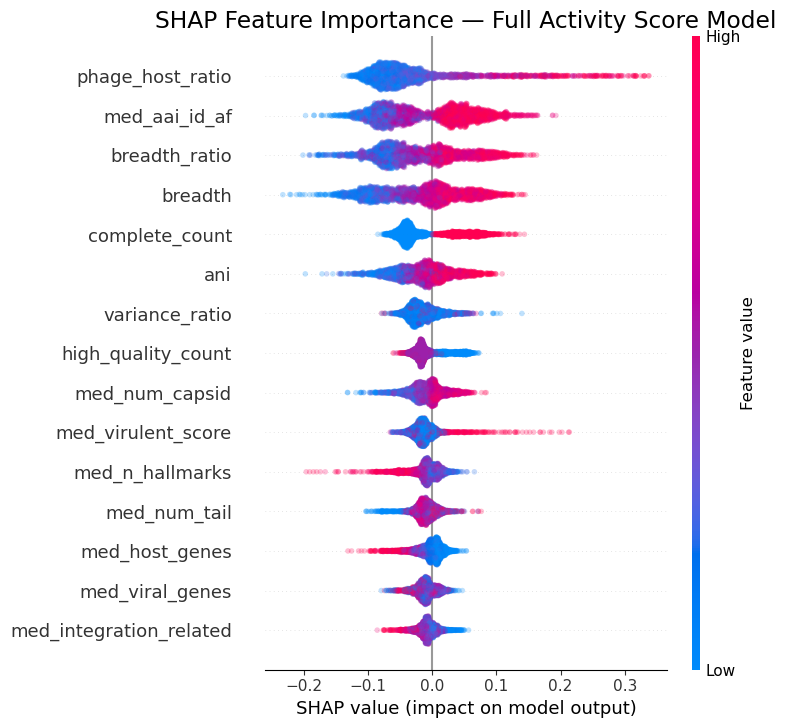

In [47]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(final_pipeline.named_steps["classifier"])
shap_explanation = explainer(X_transformed_df)

print("\nGenerating SHAP summary plot for Active class (Class 1)...")
shap.summary_plot(
    shap_explanation[:, :, 1],   
    X_transformed_df,
    max_display=15,
    plot_type="dot",
    show=False,
    alpha=0.25
)
plt.title("SHAP Feature Importance — Full Activity Score Model")
plt.tight_layout()
plt.show()

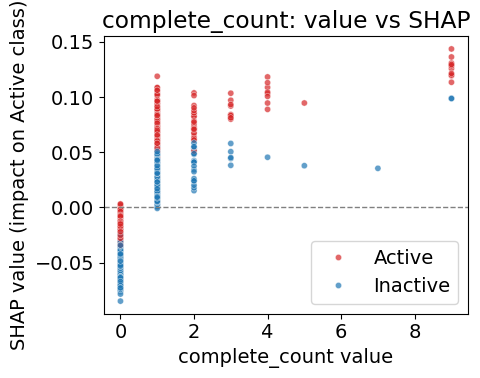

In [52]:
# Pick a feature from numeric_cols
feature_name = "complete_count"

# SHAP values for class 1 ("active")
class1_exp = shap_explanation[:, :, 1]
col_idx = X_transformed_df.columns.get_loc(feature_name)

x_vals = X_transformed_df[feature_name].values
shap_vals = class1_exp.values[:, col_idx]
activity = np.where(df["is_active"].to_numpy() == 1, "Active", "Inactive")

plot_df = pd.DataFrame({
    "feature_value": x_vals,
    "shap_value": shap_vals,
    "activity": activity
})

# If using log x-axis, keep only positive x values
plot_df = plot_df[plot_df["feature_value"] >= 0]

plt.figure(figsize=(5, 4))
sns.scatterplot(
    data=plot_df,
    x="feature_value",
    y="shap_value",
    hue="activity",
    palette={"Active": "#d62728", "Inactive": "#1f77b4"},
    s=20,
    alpha=0.7
)
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
# plt.xscale("log")
plt.xlabel(f"{feature_name} value")
plt.ylabel("SHAP value (impact on Active class)")
plt.title(f"{feature_name}: value vs SHAP")
plt.legend(title="")
plt.tight_layout()
plt.show()

In [31]:
# =============================================================================
# 10. THRESHOLD CALIBRATION & RECALL ESTIMATION
# =============================================================================
# Calculate precision, recall, and thresholds from CV results
precisions, recalls, thresholds = precision_recall_curve(all_y_test, all_y_proba)

def get_target_metrics(target_precision, precisions, recalls, thresholds):
    # Find the first index where precision meets or exceeds target
    idx = np.where(precisions >= target_precision)[0]
    if len(idx) > 0:
        return {
            "threshold": thresholds[idx[0]],
            "recall": recalls[idx[0]]
        }
    return {"threshold": 1.0, "recall": 0.0}

# Get metrics for your two targets
metrics_90 = get_target_metrics(0.90, precisions, recalls, thresholds)
metrics_75 = get_target_metrics(0.75, precisions, recalls, thresholds)
metrics_50 = get_target_metrics(0.50, precisions, recalls, thresholds)

thresh_90, recall_90 = metrics_90["threshold"], metrics_90["recall"]
thresh_75, recall_75 = metrics_75["threshold"], metrics_75["recall"]
thresh_50, recall_50 = metrics_50["threshold"], metrics_50["recall"]
print("-" * 30)
print(f"ESTIMATED PERFORMANCE (OOF):")
print(f"High Conf (90% Prec) -> Threshold: {thresh_90:.4f} | Est. Recall: {recall_90:.1%}")
print(f"Med  Conf (75% Prec) -> Threshold: {thresh_75:.4f} | Est. Recall: {recall_75:.1%}")
print(f"Low  Conf (50% Prec) -> Threshold: {thresh_50:.4f} | Est. Recall: {recall_50:.1%}")
print("-" * 30)

------------------------------
ESTIMATED PERFORMANCE (OOF):
High Conf (90% Prec) -> Threshold: 0.8400 | Est. Recall: 10.5%
Med  Conf (75% Prec) -> Threshold: 0.5500 | Est. Recall: 41.3%
Low  Conf (50% Prec) -> Threshold: 0.2600 | Est. Recall: 77.9%
------------------------------


In [32]:
import joblib

# Group the necessary metadata together
model_metadata = {
    "numeric_cols": numeric_cols,
    "thresh_90": thresh_90,
    "thresh_75": thresh_75,
    "thresh_50": thresh_50,
}

# Save the pipeline and the metadata to disk
joblib.dump(final_pipeline, "phage_activity_model_full.joblib")
joblib.dump(model_metadata, "phage_model_metadata_full.joblib")

print("Model and metadata successfully saved!")

Model and metadata successfully saved!
